### v19 feature tailoring (3class)

Drops **5** feature(s), by two criteria combined:
1. **3-selector consensus** — bottom-third by ANOVA (leave-one-user-out), cross-user permutation importance, and RandomForest (leave-one-user-out).
2. **Near-zero univariate signal** — full-data ANOVA **F < 5** (no meaningful separation).

Dropped: `gu_fore_heel_toff`, `gyro_y_std`, `heel_kurt`, `impact_mag_roll3_std`, `time_to_peak_frac`.

Note: criteria are **per-model** — e.g. `gyro_y_std` is dropped for 3-class (F≈0) but kept for 4-class (F≈13, it helps the cobblestone split). Validate against the full set with the grouped-CV check (Section~8); adopt only if grouped macro-F1 ≥ full-set.


> **XGBoost variant (full parity).** Same data/gating/feature pipeline and grouped leave-user-out evaluation as the SVM/k-NN notebooks. Runs the standard-vs-tailored preprocessing loop for parity, but XGBoost is **scale-invariant** so the tailored variant is expected to be a no-op (a fair, reportable null). Feature importance uses permutation importance for consistency across all six models. Sections 7–10 (prediction/export/CNN) omitted.

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
import os, glob, shutil

# ── Sensor groups ─────────────────────────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

# ── Surface normalisation map ─────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass',
    'dirt': 'loose', 'compact ground': 'loose', 'compacted ground': 'loose',
    'concrete': 'paved', 'asphalt': 'paved', 'exposed aggregate': 'paved', 'brick': 'paved'
}
BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + [f'pressure_{i:02d}' for i in range(1,13)]
)
SURFACE_COLORS = {'paved':'#607D8B','grass':'#4CAF50','loose':'#8D6E63','unknown':'#9E9E9E'}

# ── Composite score weights ───────────────────────────────────────────
# Rewards balanced performance across all classes, with extra weight on
# Texture/frequency features (help separate rigid paved surfaces)
W_ACC=0.30; W_MACRO_F1=0.50; W_FOCUS_F1=0.20
FOCUS_CLASS = 'loose'   # composite up-weights this (likely the minority)

# ── Merged model: drop person-confound features (per-sensor ratios + raw magnitudes) ──
# These inflate in-sample importance but hurt cross-user generalisation (proven by
# cross-user permutation importance). Kept out of the feature matrix, not the extractor.
DROP_FEATURES = ['total_p_mean','impact_mag','total_pmax','impact_mag_norm',
                 'heel_mean_ratio','fore_mean_ratio','heel_pmax_ratio','fore_pmax_ratio',
                 'heel_impulse'] + [f'pressure_{i:02d}_mean_ratio' for i in range(1,13)]

# ── Full-step filter: exclude steps whose window spans a surface transition ──
EXCLUDE_TRANSITION_STEPS    = True
TRANSITION_MIN_LABELED_FRAC = 0.80   # a kept step must be >=80% inside ONE labelled surface

# Marker columns that mean "exclude from this tag until the next tag" (NOT surfaces).
# Their regions are carved out and their steps DROPPED -- never absorbed into a
# neighbouring surface. Add any other non-surface tags you place in the raw data.
EXCLUDE_TAGS  = ['transition', 'wait']
EXCLUDE_LABEL = '__exclude__'

# ── Raw-recording quality gate (runs in Section 2 before compiling) ──
QUALITY_CHECK           = True
QUALITY_SKIP_BAD        = True       # drop recordings that FAIL the gate
QUALITY_MAX_MISSING_PCT = 5.0        # max % NaN across IMU+pressure to still pass
QUALITY_MIN_ROWS        = 100        # min rows to be usable

# ── Session-invariant texture / frequency features ────────────────────
# Target rigid-surface texture (magnitude features can't
# separate them). These are ratios / rates / spectral shape, so they carry no
# body-weight or shoe scale and should transfer across sessions. Toggle to
# ablate, then RE-RUN SECTION 2 (features are computed at compile time).
USE_TEXTURE_FEATURES = True
USE_FUSION_FEATURES  = True   # ZUPT-gated gyro+accel foot-orientation (surface unevenness)

# ── Repository layout ─────────────────────────────────────────────────
# This notebook lives in the XGBoost/ folder; the repo root is one level up.
# Rename any of these to match your actual folder names.
REPO_ROOT   = '..'
USERS_DIR   = os.path.join(REPO_ROOT, 'Individual Users')   # one subfolder per user (Amy, Catherine, Kristian, ...)
MODEL_TAG   = '3class'   # keeps this model's outputs separate from the other notebook's
OUT_ROOT    = os.path.join(REPO_ROOT, 'model_outputs', MODEL_TAG)
CHARTS_DIR  = os.path.join(OUT_ROOT, 'Charts_Graphs')       # dashboard / distribution / smoothing PNGs
PRED_DIR    = os.path.join(OUT_ROOT, 'Prediction Results')  # exported prediction CSVs
SVG_DIR     = os.path.join(OUT_ROOT, 'SVG Outputs')         # (defined for completeness)
RAW_NEW_DIR = os.path.join(REPO_ROOT, 'Raw_New Data')       # must hold exactly ONE REC_*.csv to predict on

# Compiled per-material training data frames (written in Section 2, read for training).
MATERIAL_CSVS = {
    'grass': os.path.join(REPO_ROOT, 'grass_dry.csv'),
    'loose': os.path.join(REPO_ROOT, 'loose_dry.csv'),
    'paved': os.path.join(REPO_ROOT, 'paved_dry.csv'),
}
REC_GLOB = 'REC_*.csv'   # recording file naming convention

for _d in (CHARTS_DIR, PRED_DIR, SVG_DIR):
    os.makedirs(_d, exist_ok=True)

print('Ready.')

# ── v19: pruned features = 3-selector consensus (ANOVA/perm/RF, leave-one-user-out)
#         UNION near-zero univariate signal (full-data ANOVA F < 5). Per-model. ──
TAILORED_DROP = []

# ---- permutation importance (works for any model with .predict returning class labels) ----
def _perm_importance(fitted, X, y, n_repeats=5, seed=42):
    from sklearn.metrics import f1_score as _f1
    rng=np.random.default_rng(seed)
    base=_f1(y, fitted.predict(X), average='macro')
    imp=np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        acc=[]
        for _ in range(n_repeats):
            Xp=X.copy(); Xp[:,j]=rng.permutation(Xp[:,j])
            acc.append(base-_f1(y, fitted.predict(Xp), average='macro'))
        imp[j]=np.mean(acc)
    return imp


Ready.


## 1. Core Functions

In [2]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """Parse 'x' markers to label each row with a surface. Each surface marker starts
    a region that runs until the NEXT marker. Columns named in EXCLUDE_TAGS (e.g.
    'transition', 'wait') start an EXCLUDED region (EXCLUDE_LABEL): those rows are kept
    for continuity but their steps are DROPPED downstream, never relabelled as a
    neighbouring surface."""
    surf_cols = get_surface_cols(df)
    excl_cols = [c for c in df.columns if c not in BASE_COLS and c in EXCLUDE_TAGS]
    if not surf_cols and not excl_cols: return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), SURFACE_MAP[col]))
    for col in excl_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), EXCLUDE_LABEL))
    if not events: return None
    events.sort(key=lambda e: e[0])
    df['surface'] = None
    for k, (start_idx, lab) in enumerate(events):
        end_idx = events[k+1][0] if k+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = lab
    return df[df['surface'].notna()].copy()


def step_surface_label(surf_slice, default=None, stats=None):
    """Surface for ONE step window, or (None, reason) if the step must be dropped.

    A 'transition'/'wait' marker opens an EXCLUDE_LABEL region that runs until the
    next surface marker (or the end of the recording); label_surface_segments has
    already written that region into the 'surface' column. Any step window that
    touches even one excluded row is dropped here - so a step that was in progress
    when the tag appeared, and a step that began inside the tagged region, are both
    thrown away rather than being handed the neighbouring surface's label.

    With EXCLUDE_TRANSITION_STEPS, a window carrying two different surface labels
    (it straddles a surface change) or less than TRANSITION_MIN_LABELED_FRAC of
    labelled rows (segment-edge / partial step) is dropped too. What survives is
    cleanly on one surface.

    Returns (label, reason); reason is None when the step is kept. Pass a stats
    dict to accumulate the same counters Section 2 prints.
    """
    ws = pd.Series(surf_slice)
    if (ws == EXCLUDE_LABEL).any():
        if stats is not None: stats['excluded'] += 1
        return None, 'excluded'
    lab = ws.dropna()
    if EXCLUDE_TRANSITION_STEPS:
        if stats is not None: stats['seen'] += 1
        if lab.nunique() > 1:
            if stats is not None: stats['transition'] += 1
            return None, 'transition'
        if len(lab) < TRANSITION_MIN_LABELED_FRAC * len(ws):
            if stats is not None: stats['partial'] += 1
            return None, 'partial'
        if stats is not None: stats['kept'] += 1
    if not len(lab):
        return default, None
    return lab.mode()[0], None


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df):
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in HEEL_SENSORS if s in df.columns
    )
    n=len(y_comb); sw=min(SMOOTH_WIN, n-(0 if n%2==1 else 1))
    if sw%2==0: sw-=1
    if sw<=SMOOTH_POLY: sw=SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def compute_session_stats(df):
    """
    Compute session-level normalisation anchors from the full raw recording.
    Used to remove shoe/body-weight offsets between sessions.
    """
    total_p = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    accel_y = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    valid   = total_p[total_p > 0]
    return {
        'total_p_mean': float(np.mean(valid)) if len(valid) else 1.0,
        'total_p_std':  float(np.std(valid))  if len(valid) else 1.0,
        'impact_mean':  float(np.mean(np.abs(accel_y))),
        'impact_std':   float(np.std(np.abs(accel_y))) + 1e-9,
    }


def _spec_features(sig, fs=SAMPLING_HZ, hf_cut=5.0):
    """Spectral centroid (Hz), high-freq power fraction, and normalised
    spectral entropy of a within-step signal. Linear-detrended so the stance
    loading curve doesn't dominate; power-normalised so amplitude drops out."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8 or np.allclose(x, x[0]): return 0.0, 0.0, 0.0
    t = np.arange(n); x = x - np.polyval(np.polyfit(t, x, 1), t)
    P = np.abs(np.fft.rfft(x))**2; f = np.fft.rfftfreq(n, 1.0/fs); tot = P.sum()
    if tot <= 0: return 0.0, 0.0, 0.0
    centroid = float((f*P).sum()/tot)
    hf_frac  = float(P[f >= hf_cut].sum()/tot)
    p = P/tot; p = p[p > 0]
    entropy  = float(-(p*np.log(p)).sum()/np.log(len(P))) if len(P) > 1 else 0.0
    return centroid, hf_frac, entropy


def _roughness(sig):
    """Zero-crossing rate of the detrended signal and jerk-to-signal RMS ratio.
    Both amplitude-invariant roughness proxies."""
    x = np.asarray(sig, float); n = len(x)
    if n < 4: return 0.0, 0.0
    xd = x - x.mean()
    zcr = np.sum(np.diff(np.sign(xd)) != 0) / max(n-1, 1)
    jerk = np.diff(x)
    jr  = float(np.sqrt(np.mean(jerk**2)) / (np.sqrt(np.mean(xd**2)) + 1e-9))
    return float(zcr), jr


def _ripple_frac(sig, win=SMOOTH_WIN, poly=SMOOTH_POLY):
    """Fraction of signal energy left after removing the smooth loading trend —
    i.e. relative high-frequency micro-vibration (mortar-joint chatter)."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8: return 0.0
    w = min(win, n-(0 if n % 2 == 1 else 1))
    if w % 2 == 0: w -= 1
    if w <= poly: return 0.0
    resid = x - savgol_filter(x, w, poly)
    return float(np.sum(resid**2) / (np.sum(x**2) + 1e-9))


def check_recording_quality(raw, path):
    """Scan a raw recording for missing / bad / outlier data.
    Returns (ok, report_dict). ok=False means the recording fails the gate."""
    name = os.path.basename(path)
    imu  = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
    sens = [c for c in ALL_SENSORS if c in raw.columns]
    cols = [c for c in imu + sens if c in raw.columns]
    n    = len(raw)
    num  = raw[cols].apply(pd.to_numeric, errors='coerce') if cols else pd.DataFrame()
    pct_missing = float(num.isna().mean().mean() * 100) if cols else 100.0
    soles = set(pd.to_numeric(raw['sole_id'], errors='coerce').dropna().unique()) if 'sole_id' in raw else set()
    both_soles = {1, 2} <= soles
    corrupt = int((pd.to_numeric(raw['corrupt'], errors='coerce').fillna(0) != 0).sum()) if 'corrupt' in raw else 0
    magn  = [c for c in ['magn_x','magn_y','magn_z'] if c in raw.columns]
    _scan = cols + magn                                            # include magnetometer in dead scan
    _snum = raw[_scan].apply(pd.to_numeric, errors='coerce') if _scan else pd.DataFrame()
    dead  = [c for c in _scan if _snum[c].nunique(dropna=True) <= 1]  # flatlined / dead channels
    press = raw[sens].apply(pd.to_numeric, errors='coerce') if sens else None
    n_neg = int((press < 0).sum().sum()) if press is not None else 0
    n_hi  = int((press > 5000).sum().sum()) if press is not None else 0
    gaps = 0
    if 'timestamp' in raw:
        ts = pd.to_numeric(raw['timestamp'], errors='coerce').dropna().values
        if len(ts) > 2:
            dt = np.diff(np.sort(ts)); pos = dt[dt > 0]
            med = np.median(pos) if len(pos) else 0
            gaps = int((dt > 3 * med).sum()) if med > 0 else 0
    ok = (n >= QUALITY_MIN_ROWS) and both_soles and (pct_missing <= QUALITY_MAX_MISSING_PCT)
    return ok, {'rows': n, 'both_soles': bool(both_soles), 'pct_missing': round(pct_missing, 2),
                'corrupt_rows': corrupt, 'dead_channels': len(dead), 'dead_list': ','.join(dead),
                'press_neg': n_neg, 'press_high': n_hi, 'ts_gaps': gaps,
                'verdict': 'OK' if ok else 'FAIL'}


print('Helper functions defined.')

Helper functions defined.


In [3]:
_FILTER_STATS = {'seen': 0, 'transition': 0, 'partial': 0, 'kept': 0, 'excluded': 0}

def extract_step_features(df, surface_label='unknown', foot_label='unknown', session_stats=None):
    """
    Extract enhanced per-step feature set.

    Feature groups:
    - Timing:          stance_duration, time_to_peak_frac
    - Impact:          impact_mag (raw + session-normalised), accel_mag_strike
    - Loading rate:    loading_rate (raw + session-normalised)
    - Pressure ratios: heel/fore pmax and mean as fraction of total (body-weight invariant)
    - Heel curve shape: impulse, rise/fall slope, asymmetry, skewness, kurtosis
    - Midstance:       heel-forefoot balance at midstance
    - Gyroscope:       magnitude & axes at heel strike, std across stance
    - Consistency:     rolling 3-step std of impact, loading rate, stance duration
    - Fusion (IMU):    ZUPT-gated foot-tilt range in-contact + step-to-step tilt variability
    - Per-sensor:      mean of each of 12 sensors normalised by total pressure
    """
    df = df.copy().reset_index(drop=True)
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig  = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y   = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    accel_x   = pd.to_numeric(df['accel_x'], errors='coerce').fillna(0).values
    accel_z   = pd.to_numeric(df['accel_z'], errors='coerce').fillna(0).values
    gyro_x    = pd.to_numeric(df['gyro_x'],  errors='coerce').fillna(0).values
    gyro_y    = pd.to_numeric(df['gyro_y'],  errors='coerce').fillna(0).values
    gyro_z    = pd.to_numeric(df['gyro_z'],  errors='coerce').fillna(0).values
    total_p   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values

    # ZUPT-gated fusion orientation prep (unit-free): gyro magnitude (bias-removed)
    # gates the flat/stationary instant; accel gives foot tilt there via gravity dir.
    if USE_FUSION_FEATURES:
        _gmag_full  = np.sqrt((gyro_x-np.median(gyro_x))**2 + (gyro_y-np.median(gyro_y))**2 + (gyro_z-np.median(gyro_z))**2)
        _tiltA_full = np.degrees(np.arctan2(accel_x, np.hypot(accel_y, accel_z)))
        _tiltB_full = np.degrees(np.arctan2(accel_z, np.hypot(accel_x, accel_y)))

    if session_stats is None:
        session_stats = compute_session_stats(df)

    peaks = find_step_windows(df)
    if len(peaks) < 2: return pd.DataFrame()

    _has_labels = ('surface' in df.columns) and bool(df['surface'].notna().any())
    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wax=accel_x[p1:p2]; waz=accel_z[p1:p2]
        wgx=gyro_x[p1:p2]; wgy=gyro_y[p1:p2]; wgz=gyro_z[p1:p2]
        wtp=total_p[p1:p2]; wt=t[p1:p2]
        if len(wh) < MIN_DP: continue

        # EXCLUDE-TAG + FULL-STEP filtering via the shared gate, so this path and
        # the sequence path in Section 10 keep exactly the same steps. Skipped at
        # prediction time, when there are no labels to gate on.
        _step_surf = None
        if _has_labels:
            _step_surf, _drop = step_surface_label(df['surface'].iloc[p1:p2],
                                                   default=surface_label,
                                                   stats=_FILTER_STATS)
            if _drop: continue

        n_win  = len(wh)
        c_loc  = int(np.argmin(wh))
        diff   = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc  = c_loc + int(np.argmin(diff))
        hw     = min(int(0.15 * SAMPLING_HZ), n_win - 1)
        impact = float(np.max(np.abs(way[max(0,c_loc-hw):c_loc+hw+1])))

        # Loading rate
        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy=pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
            hlo=int(np.argmin(sy)); seg=sy[hlo:min(hlo+HILL_WIN,len(sy))]
            if len(seg)<2: continue
            lp,_=find_peaks(seg,prominence=1)
            hhi=lp[0] if len(lp) else int(np.argmax(seg[1:]))+1
            rise=float(sy[hlo+hhi]-sy[hlo]); dt_lr=hhi/SAMPLING_HZ
            if dt_lr>0 and rise>MIN_DP: lr_vals.append(rise/dt_lr)
        lr = float(np.mean(lr_vals)) if lr_vals else 0.0

        # Surface label from within-step majority
        step_surf = _step_surf if _has_labels else surface_label

        stance_dur     = float(wt[-1]-wt[0]) if len(wt)>1 else 0.0
        total_p_mean_s = float(np.mean(wtp)) if len(wtp) else 1.0
        norm_denom     = max(total_p_mean_s, 1.0)
        total_pmax     = float(np.max(wtp)) if len(wtp) else 0.0
        heel_pmax_v    = float(np.max(wh))
        fore_pmax_v    = float(np.max(wf))
        heel_mean_v    = float(np.mean(wh))
        fore_mean_v    = float(np.mean(wf))

        # Heel curve temporal shape
        peak_idx_h     = int(np.argmax(wh))
        time_to_peak_f = peak_idx_h / max(n_win-1, 1)
        heel_impulse   = float(np.trapezoid(wh)) / max(n_win, 1)
        rise_slope     = (wh[peak_idx_h] - wh[0]) / max(peak_idx_h, 1)
        tail           = wh[peak_idx_h:]
        fall_slope     = (tail[-1]-tail[0]) / max(len(tail)-1,1) if len(tail)>1 else 0.0
        slope_asym     = rise_slope - abs(fall_slope)
        heel_skew_v    = float(skew(wh)) if len(wh)>2 else 0.0
        heel_kurt_v    = float(scipy_kurtosis(wh)) if len(wh)>3 else 0.0

        # Session-normalised impact and loading rate
        impact_norm = (impact - session_stats['impact_mean']) / session_stats['impact_std']
        lr_norm     = lr / max(session_stats['total_p_mean'], 1.0)

        # Gyroscope at heel strike
        gyro_sl  = slice(max(0,c_loc-hw), min(c_loc+hw+1, n_win))
        gx_s     = float(np.max(np.abs(wgx[gyro_sl]))) if len(wgx[gyro_sl]) else 0.0
        gy_s     = float(np.max(np.abs(wgy[gyro_sl]))) if len(wgy[gyro_sl]) else 0.0
        gz_s     = float(np.max(np.abs(wgz[gyro_sl]))) if len(wgz[gyro_sl]) else 0.0
        gyro_mag = float(np.sqrt(gx_s**2 + gy_s**2 + gz_s**2))

        # Resultant acceleration at strike
        accel_mag_s = float(np.max(
            np.sqrt(wax**2+way**2+waz**2)[max(0,c_loc-hw):c_loc+hw+1]
        )) if n_win > 0 else 0.0

        row = {
            'foot': foot_label, 'step_id': i, 'surface': step_surf,
            'contact_time_sec':   float(wt[0]) if len(wt) else 0.0,
            # Timing
            'stance_duration':    stance_dur,
            'time_to_peak_frac':  time_to_peak_f,
            # Impact
            'impact_mag':         impact,
            'impact_mag_norm':    impact_norm,
            'accel_mag_strike':   accel_mag_s,
            # Loading
            'loading_rate':       lr,
            'loading_rate_norm':  lr_norm,
            # Pressure ratios (body-weight invariant)
            'heel_pmax_ratio':    heel_pmax_v / max(total_pmax, 1.0),
            'fore_pmax_ratio':    fore_pmax_v / max(total_pmax, 1.0),
            'heel_mean_ratio':    heel_mean_v / norm_denom,
            'fore_mean_ratio':    fore_mean_v / norm_denom,
            'heel_fore_ratio':    heel_mean_v / (fore_mean_v + 1e-9),
            'total_pmax':         total_pmax,
            'total_p_mean':       total_p_mean_s,
            'midstance_diff':     float(whn[m_loc]-wfn[m_loc]) if m_loc<len(whn) else 0.0,
            # Heel curve shape
            'heel_impulse':       heel_impulse,
            'heel_impulse_norm':  heel_impulse / norm_denom,
            'rise_slope':         rise_slope,
            'fall_slope':         fall_slope,
            'slope_asym':         slope_asym,
            'heel_skew':          heel_skew_v,
            'heel_kurt':          heel_kurt_v,
            # Gyro
            'gyro_mag_strike':    gyro_mag,
            'gyro_x_strike':      gx_s,
            'gyro_y_strike':      gy_s,
            'gyro_z_strike':      gz_s,
            'gyro_x_std':         float(np.std(wgx)),
            'gyro_y_std':         float(np.std(wgy)),
            'gyro_z_std':         float(np.std(wgz)),
            # ── merged-in GROUND-UP features (shape / pressure-distribution / spatial dynamics) ──
        }
        # normalised total-pressure step shape
        _sc  = float(np.mean(wtp)) + 1e-9
        _xs  = np.linspace(0, 1, len(wtp)); _L = np.linspace(0, 1, 50)
        _totn  = np.interp(_L, _xs, wtp) / _sc
        _foren = np.interp(_L, _xs, wf)  / _sc
        _heeln = np.interp(_L, _xs, wh)  / _sc
        row['gu_dip_depth']       = float(1 - _totn[20:34].min()/(_totn.max()+1e-9))
        row['gu_load_first_frac'] = float(_totn[:25].sum()/(_totn.sum()+1e-9))
        row['gu_push_peak']       = float(_totn[38:].max())
        row['gu_load_slope']      = float(np.max(np.diff(_totn[:25])))
        row['gu_unload_slope']    = float(np.min(np.diff(_totn[20:40])))
        row['gu_fore_early_frac'] = float(_foren[:20].sum()/(_foren.sum()+1e-9))
        row['gu_fore_heel_toff']  = float((np.argmax(_foren)-np.argmax(_heeln))/50)
        row['gu_stance_frac']     = float((wtp > 0.5*_sc).mean())
        # 12-sensor pressure distribution (flat-foot + stance)
        _Pw = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)[p1:p2]
        _a0, _a1 = max(0, m_loc-3), min(n_win, m_loc+4); _ff = _Pw[_a0:_a1]
        _ffm = _ff.mean(0) if len(_ff) else _Pw.mean(0)
        def _pent(v):
            v=np.clip(v,0,None); tot=v.sum()
            if tot<=0: return 0.0
            q=v/tot; q=q[q>0]; return float(-(q*np.log(q)).sum()/np.log(12))
        row['gu_spatial_entropy_ff']    = _pent(_ffm)
        row['gu_spatial_entropy_stance']= _pent(_Pw.mean(0))
        row['gu_participation_ff']      = float((1/np.sum((_ffm/(_ffm.sum()+1e-9))**2))/12)
        row['gu_active_sensors']        = float((_ffm > 0.1*_ffm.max()).sum() if _ffm.max()>0 else 0)
        _Qn = _Pw/(_Pw.sum(1,keepdims=True)+1e-9)
        row['gu_cop_wander']  = float(np.mean(np.abs(np.diff(_Qn,axis=0)).sum(1))) if n_win>1 else 0.0
        row['gu_press_jitter']= float(np.mean(np.std(np.diff(_Pw,n=2,axis=0),axis=0))/_sc) if n_win>2 else 0.0
        if True:
            pass
        if USE_FUSION_FEATURES:
            _wgm  = _gmag_full[p1:p2]
            _thr  = np.percentile(_wgm, 25)
            _stat = np.where(_wgm <= _thr)[0]
            if len(_stat) < 3: _stat = np.array([int(np.argmin(_wgm))])
            _sA = _tiltA_full[p1:p2][_stat]; _sB = _tiltB_full[p1:p2][_stat]
            row['orient_rest_a']  = float(np.mean(_sA))      # dropped after roll3 (mount offset)
            row['orient_rest_b']  = float(np.mean(_sB))
            row['orient_range_a'] = float(np.ptp(_sA)) if len(_sA) > 1 else 0.0   # in-contact foot rock
            row['orient_range_b'] = float(np.ptp(_sB)) if len(_sB) > 1 else 0.0
        # Per-sensor normalised means
        for s in ALL_SENSORS:
            if s in df.columns:
                seg_s = pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
                row[f'{s}_mean_ratio'] = float(np.mean(seg_s)) / norm_denom
        if USE_TEXTURE_FEATURES:
            amag = np.sqrt(wax**2 + way**2 + waz**2)
            gmag = np.sqrt(wgx**2 + wgy**2 + wgz**2)
            a_cent, a_hf, a_ent = _spec_features(amag)
            _, g_hf, _          = _spec_features(gmag)
            a_zcr, a_jerk       = _roughness(way)
            row.update({
                'accel_spec_centroid': a_cent,
                'accel_hf_frac':       a_hf,
                'accel_spec_entropy':  a_ent,
                'accel_zcr':           a_zcr,
                'accel_jerk_ratio':    a_jerk,
                'gyro_hf_frac':        g_hf,
                'heel_ripple_frac':    _ripple_frac(wh),
            })
        rows.append(row)

    result = pd.DataFrame(rows)
    # Step-to-step rolling consistency (3-step window std)
    if len(result) >= 3:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
    else:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = 0.0
    # Fusion: step-to-step foot-tilt variability (surface unevenness across steps);
    # then drop the absolute resting tilt (sensor-mount offset, not a surface cue).
    if USE_FUSION_FEATURES and len(result):
        for col in ['orient_rest_a', 'orient_rest_b']:
            if col in result.columns:
                result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
        result = result.drop(columns=[c for c in ['orient_rest_a', 'orient_rest_b'] if c in result.columns])
    return result


def rolling_majority(series, window=5):
    """Smooth per-step predictions with a majority vote over a sliding window."""
    smoothed = series.copy()
    for i in range(len(series)):
        w = series.iloc[max(0, i-window//2):min(len(series), i+window//2+1)]
        smoothed.iloc[i] = w.mode()[0]
    return smoothed


def composite_score(acc, macro_f1, focus_f1):
    """
    Single scalar summary of model quality.
    Rewards accuracy (30%), balanced class performance (50%), and
    performance on the focus class FOCUS_CLASS (20%).
    """
    return W_ACC * acc + W_MACRO_F1 * macro_f1 + W_FOCUS_F1 * focus_f1


print('Feature extraction functions defined.')

Feature extraction functions defined.


## 2. Compile & Load Training Data (all users)

Per-surface frames `grass_dry.csv`, `loose_dry.csv`, `paved_dry.csv` are compiled from every `Individual Users/*/REC_*.csv`, with **step counts per surface** (and per user) printed. Each recording is feature-extracted with its own per-recording normalisation anchor.

In [4]:
# ── 2a. Compile per-surface frames (all users): quality gate -> full-step
#        feature extraction -> per-surface step counts ──
recordings = []
if not os.path.isdir(USERS_DIR):
    print(f'[WARN] Users folder not found: {USERS_DIR}')
else:
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if not os.path.isdir(udir): continue
        for f in sorted(glob.glob(os.path.join(udir, REC_GLOB))):
            recordings.append((user, f))
print(f'Found {len(recordings)} recording(s) across user folders.')

_FILTER_STATS.update(seen=0, transition=0, partial=0, kept=0, excluded=0)   # reset counters
quality_report, skipped = [], []
material_frames = {m: [] for m in MATERIAL_CSVS}

for user, path in recordings:
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK:
        ok, q = check_recording_quality(raw, path)
        quality_report.append({'recording': os.path.basename(path), 'user': user, **q})
        if not ok and QUALITY_SKIP_BAD:
            skipped.append(os.path.basename(path)); continue
    ss = compute_session_stats(raw)
    for sole_id, foot in [(1, 'right'), (2, 'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        labelled = label_surface_segments(sub)
        if labelled is None or len(labelled) == 0: continue
        labelled = preprocess(labelled)
        feats = extract_step_features(labelled, foot_label=foot, session_stats=ss)
        if not len(feats): continue
        feats['source_user'] = user; feats['source_recording'] = os.path.basename(path)
        for surf, grp in feats.groupby('surface'):
            if surf in material_frames: material_frames[surf].append(grp)

# ── data-quality report ──
if QUALITY_CHECK and quality_report:
    qdf = pd.DataFrame(quality_report)
    print('\n── Raw-recording quality check ──')
    show = qdf[['recording','user','rows','both_soles','pct_missing','corrupt_rows',
                'dead_channels','press_neg','press_high','ts_gaps','verdict']]
    with pd.option_context('display.max_rows', None, 'display.width', 220):
        print(show.to_string(index=False))
    nbad = int((qdf['verdict'] == 'FAIL').sum())
    print(f'{nbad} recording(s) FAILED; skipped: {skipped if skipped else "none"}')
    _dead = qdf[qdf['dead_channels'] > 0]
    if len(_dead):
        print('Dead/flatlined channels (flagged, not skipped):')
        for _, r in _dead.iterrows():
            print(f'   {r["recording"]}: {r["dead_list"]}')

# ── write per-surface frames with step counts ──
print('\nPer-surface training data (full steps only):')
_tot = 0
for surf, out in MATERIAL_CSVS.items():
    if material_frames[surf]:
        mdf = pd.concat(material_frames[surf], ignore_index=True); mdf.to_csv(out, index=False); _tot += len(mdf)
        print(f'  {surf:6s}: {len(mdf):6d} steps  from {mdf["source_recording"].nunique():2d} recording(s)'
              f'  across {mdf["source_user"].nunique()} user(s)  -> {os.path.basename(out)}')
    else:
        print(f'  {surf:6s}:      0 steps  [WARN] none found; {os.path.basename(out)} not written')
print(f'  TOTAL : {_tot} steps')

# ── exclude-tag + full-step filter summary ──
fs = _FILTER_STATS
print(f'\nExcluded-region steps dropped (transition/wait tags): {fs["excluded"]}')
if EXCLUDE_TRANSITION_STEPS:
    print(f'Full-step filter: kept {fs["kept"]}, dropped {fs["transition"]} transition-spanning '
          f'+ {fs["partial"]} partial/edge (of {fs["seen"]} candidate labelled steps).')

# ── steps per user x surface (coverage check) ──
_allf = pd.concat([g for lst in material_frames.values() for g in lst], ignore_index=True) if any(material_frames.values()) else None
if _allf is not None:
    print('\nSteps per user x surface:')
    print(_allf.pivot_table(index='source_user', columns='surface', values='step_id',
                            aggfunc='count', fill_value=0).to_string())

Found 53 recording(s) across user folders.

── Raw-recording quality check ──
              recording      user  rows  both_soles  pct_missing  corrupt_rows  dead_channels  press_neg  press_high  ts_gaps verdict
     REC_0811_00000.csv Catherine  9770        True          0.0             0              3          0           0        0      OK
REC_20260519_154549.csv Catherine 13445        True          0.0             0              3          0           0        0      OK
REC_20260520_190100.csv Catherine 17898        True          0.0             0              3          0           0        0      OK
REC_20260811_193525.csv Catherine 38930        True          0.0             0              3          0           0        0      OK
REC_20260514_173731.csv  Kristian  4304        True          0.0             0              3          0           0        0      OK
REC_20260514_173910.csv  Kristian 13266        True          0.0             0              3          0           0  

### 2b. Load the compiled material files for training

In [4]:
all_frames = []
for surf, path in MATERIAL_CSVS.items():
    if not os.path.exists(path):
        print(f'  [SKIP] {os.path.basename(path)} not found')
        continue
    mdf = pd.read_csv(path)
    all_frames.append(mdf)
    print(f'  {os.path.basename(path)}: {len(mdf)} steps')

full_df = pd.concat(all_frames, ignore_index=True)
print(f'\nTotal steps: {len(full_df)}')
print('Surface distribution:')
print(full_df['surface'].value_counts().to_string())

  grass_dry.csv: 3766 steps
  loose_dry.csv: 2002 steps
  paved_dry.csv: 9896 steps

Total steps: 15664
Surface distribution:
surface
paved    9896
grass    3766
loose    2002


## 3. Prepare Feature Matrix

In [5]:
META_COLS    = ['foot', 'step_id', 'surface', 'contact_time_sec',
                'source_user', 'source_recording']
FEATURE_COLS = [c for c in full_df.columns if c not in META_COLS and c not in DROP_FEATURES and c not in TAILORED_DROP]

# ---- OPTIONAL: keep-only allowlist (features to USE, instead of features to DROP) ----
# Leave empty [] to use the normal drop-based selection above.
# If non-empty, ONLY these features are used. The dedup guard below removes any accidental repeats;
# features not present in the data are ignored with a warning.
KEEP_ONLY = ['orient_rest_a_roll3_std', 'gyro_x_std', 'gyro_hf_frac', 'orient_rest_b_roll3_std', 'accel_spec_entropy', 'accel_jerk_ratio', 'gu_spatial_entropy_ff', 'gu_fore_heel_toff', 'accel_spec_centroid', 'orient_range_b', 'gu_press_jitter', 'orient_range_a', 'accel_hf_frac']

if KEEP_ONLY:
    _missing  = [f for f in KEEP_ONLY if f not in full_df.columns]
    _confound = [f for f in KEEP_ONLY if f in DROP_FEATURES]
    if _missing:  print(f'[KEEP_ONLY] not in data, ignored: {_missing}')
    if _confound: print(f'[KEEP_ONLY] warning: person-confound features normally dropped: {_confound}')
    FEATURE_COLS = [f for f in KEEP_ONLY if f in full_df.columns]
    print(f'[KEEP_ONLY active] using {len(FEATURE_COLS)} specified features (drop-list bypassed)')
else:
    print(f'[KEEP_ONLY inactive] using drop-based selection: {len(FEATURE_COLS)} features')

print(f'[v19] tailored-out {len([c for c in full_df.columns if c in TAILORED_DROP])} consensus-weak features: {sorted(set(full_df.columns)&set(TAILORED_DROP))}')
print(f'Dropped {len([c for c in full_df.columns if c in DROP_FEATURES])} person-confound features (per-sensor ratios + raw magnitudes)')

train_df  = full_df.dropna(subset=['surface']).copy()
# ---- dedup guard: a repeated name (e.g. from a KEEP_ONLY typo) would duplicate a column
# in the training matrix (double-counting, esp. bad for k-NN/SVM) and crash pandas reindex.
_before = list(FEATURE_COLS)
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))
if len(FEATURE_COLS) != len(_before):
    from collections import Counter as _Cc
    print('[dedup] removed duplicate feature name(s) from FEATURE_COLS:',
          [k for k,v in _Cc(_before).items() if v>1])
X_tr      = train_df[FEATURE_COLS].fillna(0).values
y_tr      = train_df['surface'].values
le        = LabelEncoder()
y_tr_enc  = le.fit_transform(y_tr)
classes   = le.classes_
focus_idx = list(classes).index(FOCUS_CLASS) if FOCUS_CLASS in classes else 0
if FOCUS_CLASS not in classes:
    print(f'[WARN] FOCUS_CLASS {FOCUS_CLASS!r} not present in data; focusing on {classes[0]!r}.')

print(f'Feature matrix: {X_tr.shape[0]} steps × {X_tr.shape[1]} features')
print(f'Classes: {classes}')
print(f'Class counts: {dict(zip(*np.unique(y_tr, return_counts=True)))}')

# ── Grouped cross-validation setup ────────────────────────────────────
# Steps from the SAME recording must not straddle train/test folds, or the
# model can lean on per-recording normalisation to recognise a session it
# has partly seen — inflating scores (minority class most of all). Group by recording;
# switch to 'source_user' for the stricter "predict a new person" test.
CV_GROUP = 'source_recording'
if CV_GROUP in train_df.columns:
    GROUPED  = True
    groups   = train_df[CV_GROUP].values
    _gcount  = train_df.groupby('surface')[CV_GROUP].nunique()
    N_SPLITS = int(min(5, _gcount.min()))
    print(f'\nGrouped CV by "{CV_GROUP}" — distinct groups per class:')
    print(_gcount.to_string())
    if N_SPLITS < 5:
        print(f'[WARN] rarest class spans only {int(_gcount.min())} group(s) → {N_SPLITS}-fold grouped CV.')
        print(f'       Few independent {FOCUS_CLASS} sessions = a noisy {FOCUS_CLASS} estimate; more {FOCUS_CLASS} recordings is the real fix.')
    if N_SPLITS < 2:
        raise ValueError('Rarest class appears in <2 recordings — grouped CV impossible. Collect more sessions.')
else:
    GROUPED = False; groups = None; N_SPLITS = 5
    print('\n[WARN] No group column found — re-run Section 2 to regenerate material files with source columns.')
    print(f'       Falling back to shuffled (ungrouped) CV; {FOCUS_CLASS} scores may be optimistic due to leakage.')

[KEEP_ONLY active] using 13 specified features (drop-list bypassed)
[v19] tailored-out 0 consensus-weak features: []
Dropped 21 person-confound features (per-sensor ratios + raw magnitudes)
Feature matrix: 15664 steps × 13 features
Classes: ['grass' 'loose' 'paved']
Class counts: {'grass': np.int64(3766), 'loose': np.int64(2002), 'paved': np.int64(9896)}

Grouped CV by "source_recording" — distinct groups per class:
surface
grass    30
loose    16
paved    47


## 4. Train & Compare: Random Forest vs XGBoost

In [6]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# ── SINGLE classifier: XGBoost ── grouped leave-user-out; evaluated on the SAME protocol as
# the SVM/k-NN notebooks so the six models are directly comparable.
# NOTE: XGBoost is scale-INVARIANT, so the 'tailored' preprocessing variant is expected to be a
# NO-OP relative to 'standard' — we run both anyway for parity, and that null result is itself a
# fair finding (tree models don't need the preprocessing SVM/k-NN require).
CLASS_WEIGHT_STRENGTH = 0.5
SUBSAMPLE_PER_CLASS = None            # XGBoost is cheap; use all data
RUN_VARIANTS = ['standard', 'tailored']

def soft_sample_weight(y, strength):
    if strength <= 0: return None
    cs, cnt = np.unique(y, return_counts=True); n, k = len(y), len(cs)
    w = {c: (n/(k*ct))**strength for c, ct in zip(cs, cnt)}
    return np.array([w[v] for v in y])

splitter = (StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
            if GROUPED else StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42))

def make_prep(kind):
    return ('prep', StandardScaler()) if kind=='standard' else ('prep', PowerTransformer(method='yeo-johnson', standardize=True))

def make_pipe(kind):
    return Pipeline([make_prep(kind),
        ('clf', XGBClassifier(max_depth=4, n_estimators=250, learning_rate=0.05,
                              subsample=0.9, colsample_bytree=0.8, eval_metric='mlogloss',
                              random_state=42, verbosity=0))])

_le = LabelEncoder().fit(classes)
def oof_predict(kind, y):
    oof = np.empty(len(y), dtype=object)
    for tr, te in splitter.split(X_tr, y, groups):
        p = make_pipe(kind)
        sw = soft_sample_weight(y[tr], CLASS_WEIGHT_STRENGTH)
        p.fit(X_tr[tr], _le.transform(y[tr]), clf__sample_weight=sw)
        oof[te] = _le.inverse_transform(p.predict(X_tr[te]))
    return oof

results = {}
for kind in RUN_VARIANTS:
    y_cv = oof_predict(kind, y_tr).astype(str)
    acc_ = accuracy_score(y_tr, y_cv); f1_ = f1_score(y_tr, y_cv, labels=classes, average=None)
    mf1_ = float(np.mean(f1_)); cs_ = composite_score(acc_, mf1_, f1_[focus_idx])
    results[kind] = dict(y_cv=y_cv, acc=acc_, f1=f1_, mf1=mf1_, cs=cs_)
    print(f'[{kind:8s}] Acc {acc_*100:.1f}%  MacroF1 {mf1_*100:.1f}%  {FOCUS_CLASS} F1 {f1_[focus_idx]*100:.1f}%  Composite {cs_*100:.1f}%')
    print(f'           per-class F1: ' + '  '.join(f'{c} {v*100:.1f}%' for c,v in zip(classes, f1_)))

best_kind = max(results, key=lambda k: results[k]['cs'])
r = results[best_kind]
acc, f1, mf1, cs, y_cv_best = r['acc'], r['f1'], r['mf1'], r['cs'], r['y_cv']
best_name = f'XGBoost ({best_kind} preprocessing)'
# fit final for dashboard; sample_weight on all data
best_pipe = make_pipe(best_kind)
best_pipe.fit(X_tr, _le.transform(y_tr), clf__sample_weight=soft_sample_weight(y_tr, CLASS_WEIGHT_STRENGTH))
# wrap predict so downstream perm-importance / dashboard get STRING labels
class _StrWrap:
    def __init__(self, pipe, le): self.pipe=pipe; self.le=le
    def fit(self,X,y,sample_weight=None):
        if sample_weight is None: self.pipe.fit(X, self.le.transform(y))
        else: self.pipe.fit(X, self.le.transform(y), clf__sample_weight=sample_weight)
        return self
    def predict(self,X): return self.le.inverse_transform(self.pipe.predict(X))
best_pipe = _StrWrap(best_pipe, _le)
use_encoded = False
print(f'\n>> dashboard uses: {best_name}  (Composite {cs*100:.1f}%)')
if len(RUN_VARIANTS)==2:
    d=(results['tailored']['cs']-results['standard']['cs'])*100
    print(f'   tailored - standard composite: {d:+.1f} pts (expected ~0 for trees; scale-invariant)')


[standard] Acc 75.9%  MacroF1 62.3%  loose F1 27.4%  Composite 59.4%
           per-class F1: grass 74.3%  loose 27.4%  paved 85.1%
[tailored] Acc 75.8%  MacroF1 62.2%  loose F1 27.2%  Composite 59.3%
           per-class F1: grass 74.3%  loose 27.2%  paved 85.0%

>> dashboard uses: XGBoost (standard preprocessing)  (Composite 59.4%)
   tailored - standard composite: -0.1 pts (expected ~0 for trees; scale-invariant)


## 5. Dashboard — Scores, Confusion Matrices, Feature Importance

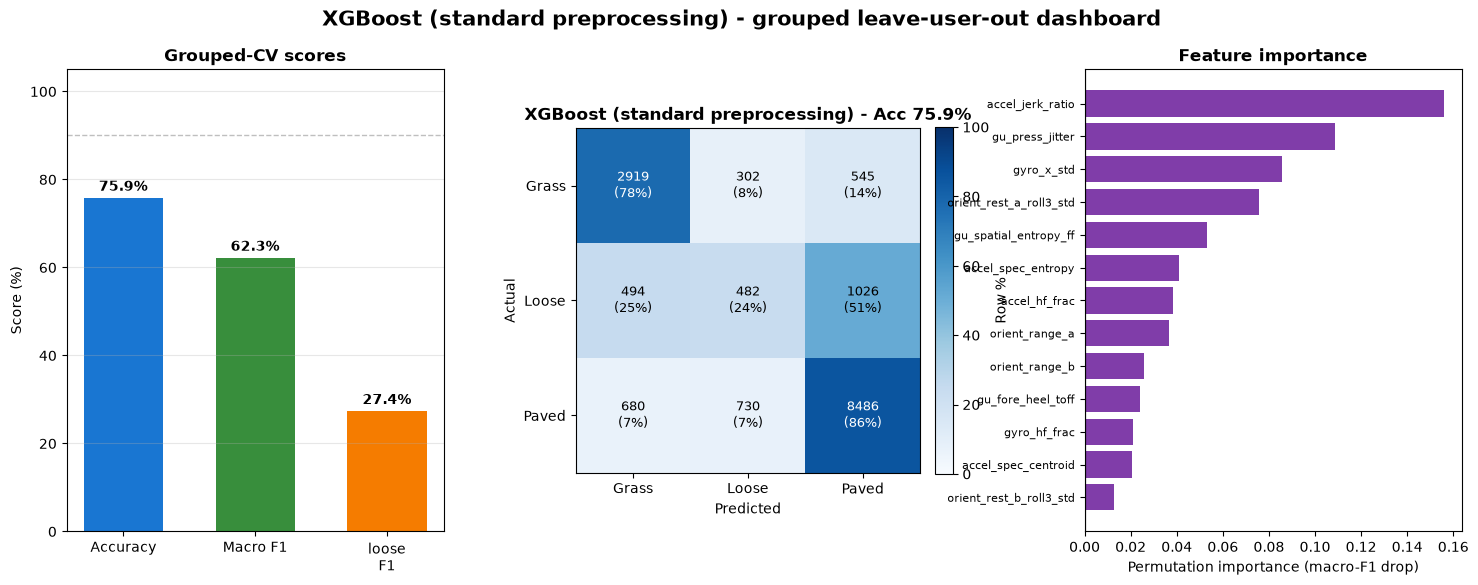

In [78]:
# ===== Dashboard: scores, confusion matrix, permutation feature importance =====
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix

fig = plt.figure(figsize=(18, 6))
fig.suptitle(f'{best_name} - grouped leave-user-out dashboard', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# (1) score bars
ax = fig.add_subplot(gs[0,0])
vals = [acc*100, mf1*100, f1[focus_idx]*100]
bars = ax.bar(['Accuracy','Macro F1', f'{FOCUS_CLASS}\nF1'], vals,
              color=['#1976D2','#388E3C','#F57C00'], width=0.6)
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0,105); ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_ylabel('Score (%)'); ax.set_title('Grouped-CV scores', fontweight='bold'); ax.grid(axis='y', alpha=0.3)

# (2) confusion matrix (row-normalised %) from out-of-fold predictions
ax = fig.add_subplot(gs[0,1])
cm = confusion_matrix(y_tr, y_cv_best, labels=classes)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(len(classes))); ax.set_xticklabels([c.capitalize() for c in classes])
ax.set_yticks(range(len(classes))); ax.set_yticklabels([c.capitalize() for c in classes])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'{best_name} - Acc {acc*100:.1f}%', fontweight='bold')
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{cm[i,j]}\n({cm_n[i,j]:.0f}%)', ha='center', va='center',
                fontsize=9, color='white' if cm_n[i,j] > 55 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Row %')

# (3) permutation feature importance (consistent across all six models)
ax = fig.add_subplot(gs[0,2])
imp = _perm_importance(best_pipe, X_tr, y_tr)
top_n = min(15, len(imp)); order = np.argsort(imp)[::-1][:top_n]
ax.barh(range(top_n), imp[order][::-1], color='#6A1B9A', alpha=0.85)
ax.set_yticks(range(top_n)); ax.set_yticklabels([FEATURE_COLS[i] for i in order[::-1]], fontsize=8)
ax.set_xlabel('Permutation importance (macro-F1 drop)')
ax.set_title('Feature importance', fontweight='bold'); ax.axvline(0, color='k', lw=0.8)

plt.tight_layout(rect=[0,0,1,0.94]); plt.show()


## 6. Feature Distributions by Surface

The eight features that best **separate the three surfaces**, chosen automatically by ANOVA F-statistic over the model's feature set (higher F = larger between-class vs. within-class variance). Each panel overlays the per-surface distributions; where the coloured humps sit apart, that feature discriminates the classes.

Most class-differentiable features (ANOVA F):
orient_rest_a_roll3_std    2237.9
gyro_x_std                 1127.4
accel_jerk_ratio           1043.3
orient_rest_b_roll3_std    1006.5
accel_spec_centroid         606.4
accel_hf_frac               585.0
accel_spec_entropy          583.6
gyro_hf_frac                411.4
orient_range_a               84.5
gu_press_jitter              59.0
gu_spatial_entropy_ff        23.5
orient_range_b               22.9


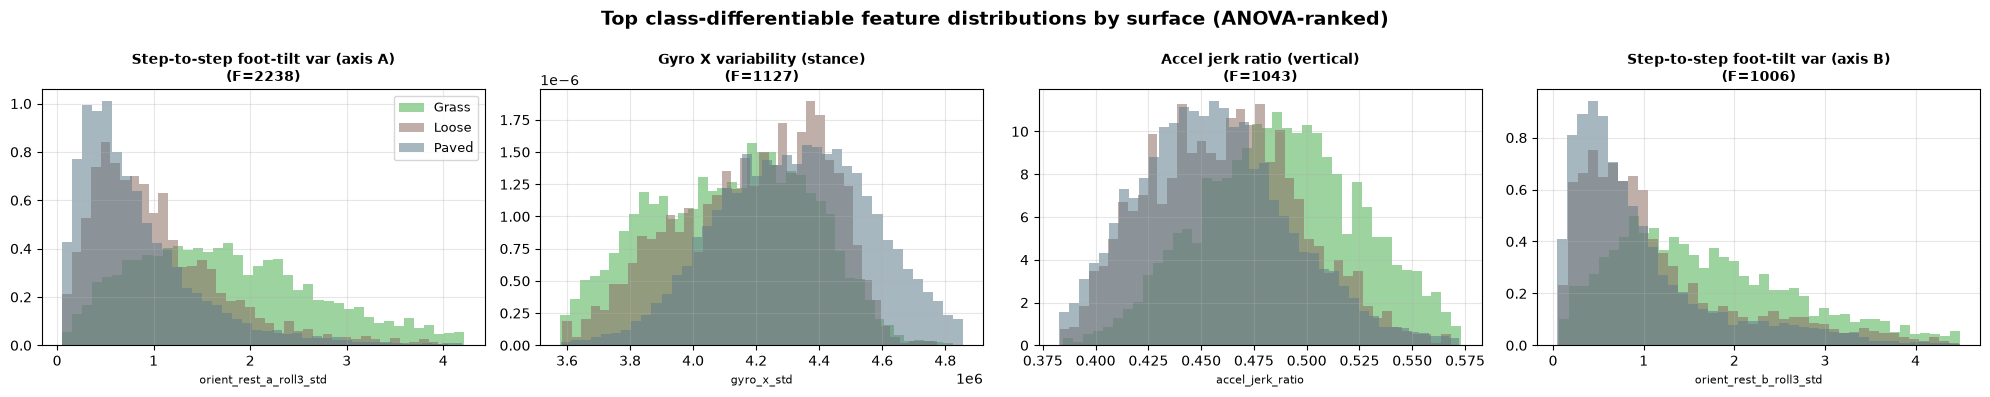

In [12]:
# ===== Section 6: distributions of the MOST CLASS-DIFFERENTIABLE features =====
# Instead of a hand-picked list, rank the model's own features (FEATURE_COLS) by how
# well they separate the surfaces, using the ANOVA F-statistic (between-class variance
# / within-class variance). Then plot the top 8. This always matches the features the
# model actually uses and highlights the ones that carry the class signal.
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler as _SS

_Xz = _SS().fit_transform(train_df[FEATURE_COLS].fillna(0).values)
_F, _p = f_classif(_Xz, train_df['surface'].values)
fsep = pd.Series(_F, index=FEATURE_COLS).sort_values(ascending=False)
key_feats = fsep.head(4).index.tolist()
print('Most class-differentiable features (ANOVA F):')
print(fsep.head(12).round(1).to_string())

_nice = {'orient_rest_a_roll3_std':'Step-to-step foot-tilt var (axis A)',
         'orient_rest_b_roll3_std':'Step-to-step foot-tilt var (axis B)',
         'accel_jerk_ratio':'Accel jerk ratio (vertical)','gyro_x_std':'Gyro X variability (stance)',
         'stance_duration':'Stance duration','gyro_x_strike':'Gyro X at strike',
         'accel_hf_frac':'Accel high-freq fraction'}

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 4))
fig2.suptitle('Top class-differentiable feature distributions by surface (ANOVA-ranked)',
              fontsize=14, fontweight='bold')
for ax, feat in zip(axes2.flat, key_feats):
    vals_all = train_df[feat].replace([np.inf,-np.inf], np.nan).dropna()
    lo, hi = vals_all.quantile(0.01), vals_all.quantile(0.99)          # clip outliers for readability
    for surf in list(classes):
        v = train_df[train_df['surface']==surf][feat]
        v = v[(v>=lo)&(v<=hi)].dropna()
        ax.hist(v, bins=40, alpha=0.55, color=SURFACE_COLORS.get(surf,'#9E9E9E'),
                label=str(surf).capitalize(), density=True)
    ax.set_title(f"{_nice.get(feat, feat)}\n(F={fsep[feat]:.0f})", fontweight='bold', fontsize=10)
    ax.set_xlabel(feat, fontsize=8); ax.grid(alpha=0.3)
    if feat == key_feats[0]: ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'feature_distributions.png'), bbox_inches='tight', dpi=150)
plt.show()

### Train & evaluate under grouped CV

### Compare to the tree baseline (grouped CV)

### CNN confusion matrix (grouped CV)

## 11. Appendix — feature importance, pruning, and hardness / evenness scales

**Which features matter (and which to drop).** In-sample RandomForest importance tells you what the model *uses*, but that includes person-confounds. The honest test is **cross-user (leave-one-user-out) permutation importance**: shuffle each feature and measure how much it hurts prediction on a *held-out person*. Features with importance ≤ 0 don't help a new user and are prune candidates — the cell then **re-tests user-grouped macro F1 with them removed** so you can see if pruning actually helps. Repeat: prune the clearly-negative ones, re-run, keep what improves or holds.

**Hardness / evenness scales.** Two interpretable per-step axes: hardness = out-of-fold P(firm) from compliance features; evenness = inverted irregularity composite. The plots show how the surfaces populate each axis.

Feature importance for: XGBoost (standard preprocessing)
TOP cross-user features:
                         crossuser_perm(x1000)  insample_perm
orient_rest_a_roll3_std                   54.9         0.0755
accel_jerk_ratio                          29.3         0.1558
accel_spec_centroid                       13.3         0.0204
accel_spec_entropy                        13.0         0.0411
gyro_x_std                                12.1         0.0855
orient_rest_b_roll3_std                    8.4         0.0128
accel_hf_frac                              6.0         0.0383
gu_fore_heel_toff                          5.8         0.0241
gu_press_jitter                            4.0         0.1087
gyro_hf_frac                               2.3         0.0212
gu_spatial_entropy_ff                      1.9         0.0531
orient_range_a                             1.8         0.0366

BOTTOM (hurt/useless for a new user):
                         crossuser_perm(x1000)  insample_perm
orient_rest

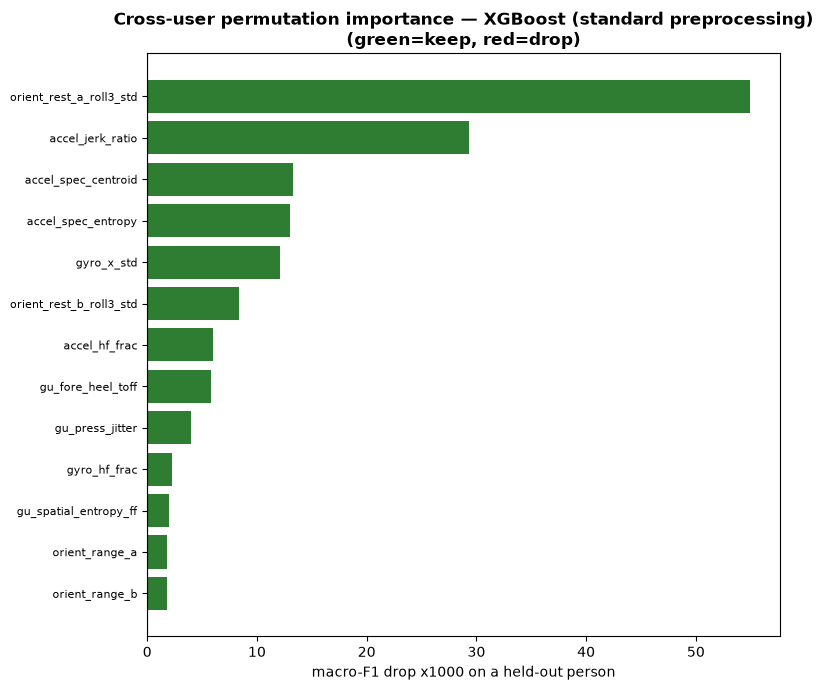

In [74]:
# subsample helper (defined here; XGBoost training uses SUBSAMPLE_PER_CLASS=None so this is
# a passthrough unless you set a cap. Present so the appendix's _fit_sub can call it.)
def _subsample_idx(idx, yv, per_class, seed=42):
    if not per_class: return idx
    rng=np.random.default_rng(seed); keep=[]
    for c in np.unique(yv[idx]):
        ci=idx[yv[idx]==c]; keep+=list(rng.choice(ci,min(len(ci),per_class),replace=False))
    return np.array(sorted(keep))

# ===== (A/B/C) feature importance for THIS classifier + honest cross-user pruning =====
# NOTE: importance is measured for the notebook's OWN classifier (make_pipe / best_kind),
# not a surrogate model. Permutation importance is used throughout (k-NN/SVM have no
# built-in importances). Kernel SVMs reuse the training SUBSAMPLE_PER_CLASS to stay tractable.
from sklearn.model_selection import StratifiedGroupKFold as _SGK
from sklearn.metrics import f1_score as _f1

_raw_feats = list(FEATURE_COLS)                   # from Section 3 (confounds already excluded)
# dedupe (a repeated column name would break pandas reindex below)
FEATS = list(dict.fromkeys(_raw_feats))
if len(FEATS) != len(_raw_feats):
    from collections import Counter as _C
    _dups=[k for k,v in _C(_raw_feats).items() if v>1]
    print(f'[warning] removed duplicate feature name(s) from FEATURE_COLS: {_dups}')
Xa = full_df[FEATS].fillna(0).values; ya = full_df['surface'].values
usr = full_df['source_user'].values; users = sorted(set(usr)); classes_a = sorted(set(ya))

def _fit_sub(cols_idx, tr):
    """Fit THIS classifier on a (subsampled) train fold, on the given feature columns."""
    tr = _subsample_idx(tr, ya, SUBSAMPLE_PER_CLASS)
    m = _StrWrap(make_pipe(best_kind), _le)
    m.fit(Xa[np.ix_(tr, cols_idx)], ya[tr])
    return m

# (A) in-sample permutation importance of THIS classifier (all data, no grouping)
_allcols = list(range(len(FEATS)))
_m_all = _StrWrap(make_pipe(best_kind), _le); _m_all.fit(Xa, ya, sample_weight=soft_sample_weight(ya, CLASS_WEIGHT_STRENGTH))
insamp = pd.Series(_perm_importance(_m_all, Xa, ya), index=FEATS)

# (B) cross-user (leave-one-user-out) permutation importance of THIS classifier
_rng = np.random.default_rng(0); _drops = {f: [] for f in FEATS}
for u in users:
    tr = np.where(usr != u)[0]; te = np.where(usr == u)[0]
    if len(set(ya[tr])) < len(classes_a): continue
    _m = _fit_sub(_allcols, tr)
    base = _f1(ya[te], _m.predict(Xa[te]), labels=classes_a, average='macro')
    Xte = Xa[te].copy()
    for j, f in enumerate(FEATS):
        col = Xte[:, j].copy(); dd = []
        for _ in range(2):
            Xte[:, j] = _rng.permutation(col)
            dd.append(base - _f1(ya[te], _m.predict(Xte), labels=classes_a, average='macro'))
        Xte[:, j] = col; _drops[f].append(np.mean(dd))
perm = (pd.Series({f: np.mean(v) if v else 0.0 for f, v in _drops.items()}) * 1000).sort_values(ascending=False)
cmp = pd.DataFrame({'crossuser_perm(x1000)': perm.round(1),
                    'insample_perm': insamp[~insamp.index.duplicated()].reindex(perm.index).round(4)})
print(f'Feature importance for: {best_name}')
print('TOP cross-user features:'); print(cmp.head(12).to_string())
print('\nBOTTOM (hurt/useless for a new user):'); print(cmp.tail(8).to_string())
PRUNE = perm[perm <= 0].index.tolist()
print(f'\nPrune candidates (<=0 cross-user): {len(PRUNE)}'); print(PRUNE)

# (C) prune-and-retest under USER-grouped CV, with THIS classifier
def _ug_macro(cols):
    ci = [FEATS.index(c) for c in cols]; oof = np.empty(len(ya), object)
    for tr, te in _SGK(N_SPLITS, shuffle=True, random_state=42).split(Xa[:, ci], ya, usr):
        if len(set(ya[tr])) < len(classes_a): continue
        m = _fit_sub(ci, tr); oof[te] = m.predict(Xa[np.ix_(te, ci)])
    fill = oof != None
    return _f1(ya[fill], oof[fill].astype(str), average='macro') * 100
_kept = [c for c in FEATS if c not in PRUNE]
print(f'\nUser-grouped macro F1 ({best_name}):  all {len(FEATS)} = {_ug_macro(FEATS):.1f}%   '
      f'|   pruned to {len(_kept)} = {_ug_macro(_kept):.1f}%')
print('If pruned >= all, adopt PRUNED_FEATURES = _kept for the final model.')

fig, ax = plt.subplots(figsize=(8, 7)); top = perm.head(20)[::-1]
ax.barh(range(len(top)), top.values, color=['#C62828' if v <= 0 else '#2E7D32' for v in top.values])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8); ax.axvline(0, color='k', lw=0.8)
ax.set_title(f'Cross-user permutation importance — {best_name}\n(green=keep, red=drop)', fontweight='bold')
ax.set_xlabel('macro-F1 drop x1000 on a held-out person')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'crossuser_importance.png'), dpi=140, bbox_inches='tight'); plt.show()


### 11b. Cross-recording feature importance (new-session generalisation)

Parallel to the cross-user analysis above, but grouping by `source_recording` instead of `source_user`. This is the **use-case-relevant** test: the primary goal is predicting a **new walk/session** (often from people already represented), not a brand-new person. Cross-user stays as the stricter new-person stress test.

Read the two columns **together**: a feature that helps cross-recording but *hurts* cross-user is a **person-fingerprint** (flagged in the table). The recording-grouped F1 is your new-session number; the user-grouped F1 is your new-person number — report both, they answer different questions.

*4-class caveat:* `modular_paved` spans few recordings (Sam-only), so its cross-recording importance is thin and cannot separate surface from person — provisional until multi-user cobblestone exists.

recordings per class: {'grass': 30, 'loose': 16, 'paved': 47}

TOP cross-recording features (side by side with cross-user):
                           crossrec_perm(x1000)  crossuser_perm(x1000)                fingerprint?
accel_jerk_ratio                           83.6                   25.3                            
gyro_x_std                                 55.7                   23.5                            
accel_mag_strike                           45.1                    0.7                            
orient_rest_a_roll3_std                    40.3                   63.3                            
gu_cop_wander                              39.7                    8.6                            
gu_dip_depth                               22.7                    0.0                            
accel_spec_centroid                        19.4                   18.7                            
gyro_x_strike                              18.4                    2.9              

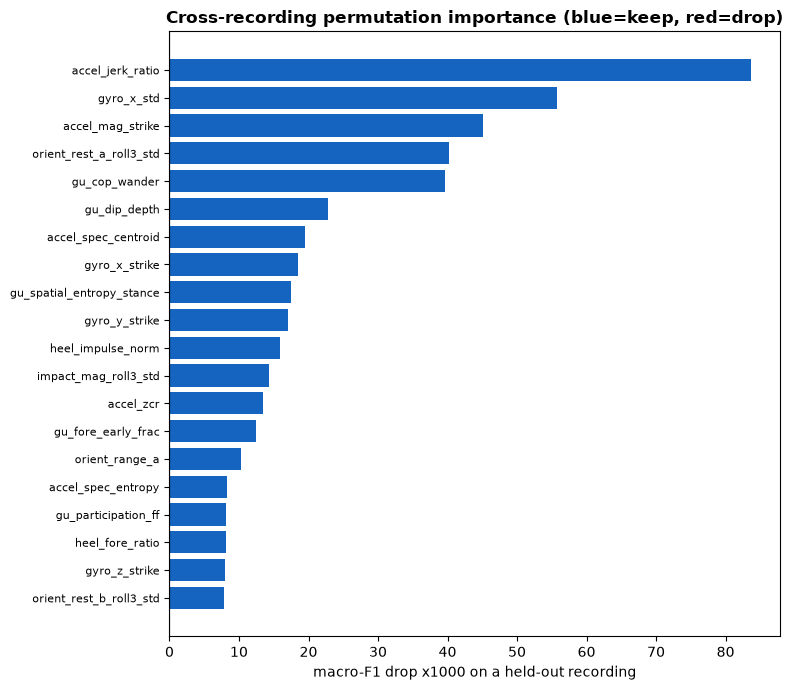

In [17]:
# ===== (A2/B2/C2) cross-RECORDING importance for THIS classifier =====
# Same as the cross-user cell but grouping by source_recording (the new-session question).
# Uses the notebook's OWN classifier; kernel SVMs reuse SUBSAMPLE_PER_CLASS.
from sklearn.model_selection import StratifiedGroupKFold as _SGKr
from sklearn.metrics import f1_score as _f1r

FEATS_r = list(FEATURE_COLS)
Xr = full_df[FEATS_r].fillna(0).values; yr = full_df['surface'].values
recs = full_df['source_recording'].values; classes_r = sorted(set(yr))
_rec_per_cls = {c: len(set(recs[yr==c])) for c in classes_r}
print('recordings per class:', _rec_per_cls)
if min(_rec_per_cls.values()) < 5:
    _thin=[c for c,n in _rec_per_cls.items() if n<5]
    print(f'[CAVEAT] class(es) {_thin} span <5 recordings -> cross-recording importance thin; provisional.')
_ns = max(2, min(5, min(_rec_per_cls.values())))

def _fit_sub_r(cols_idx, tr):
    tr = _subsample_idx(tr, yr, SUBSAMPLE_PER_CLASS)
    m = _StrWrap(make_pipe(best_kind), _le); m.fit(Xr[np.ix_(tr, cols_idx)], yr[tr], sample_weight=soft_sample_weight(yr[tr], CLASS_WEIGHT_STRENGTH)); return m

_allcols_r = list(range(len(FEATS_r)))
_rng_r = np.random.default_rng(0); _drops_r = {f: [] for f in FEATS_r}
for tr, te in _SGKr(_ns, shuffle=True, random_state=0).split(Xr, yr, recs):
    if len(set(yr[tr])) < len(classes_r): continue
    _m = _fit_sub_r(_allcols_r, tr)
    base = _f1r(yr[te], _m.predict(Xr[te]), labels=classes_r, average='macro')
    Xte = Xr[te].copy()
    for j, f in enumerate(FEATS_r):
        col = Xte[:, j].copy(); dd = []
        for _ in range(2):
            Xte[:, j] = _rng_r.permutation(col)
            dd.append(base - _f1r(yr[te], _m.predict(Xte), labels=classes_r, average='macro'))
        Xte[:, j] = col; _drops_r[f].append(np.mean(dd))
perm_r = (pd.Series({f: np.mean(v) if v else 0.0 for f, v in _drops_r.items()}) * 1000).sort_values(ascending=False)

_cols = {'crossrec_perm(x1000)': perm_r.round(1)}
try: _cols['crossuser_perm(x1000)'] = perm.reindex(perm_r.index).round(1)
except NameError: pass
cmp_r = pd.DataFrame(_cols)
if 'crossuser_perm(x1000)' in cmp_r:
    cmp_r['fingerprint?'] = ['<-- likely person-confound' if (r>0 and (u is not None and u<0)) else ''
                             for r,u in zip(cmp_r['crossrec_perm(x1000)'], cmp_r['crossuser_perm(x1000)'])]
print(f'\nFeature importance for: {best_name}')
print('TOP cross-recording features (side by side with cross-user):'); print(cmp_r.head(14).to_string())
print('\nBOTTOM (weak for a new recording):'); print(cmp_r.tail(8).to_string())
PRUNE_REC = perm_r[perm_r <= 0].index.tolist()
print(f'\nWeak-for-new-recording (<=0): {len(PRUNE_REC)}  {PRUNE_REC}')

def _rg_macro(cols):
    ci=[FEATS_r.index(c) for c in cols]; oof=np.empty(len(yr),object); fill=np.zeros(len(yr),bool)
    for tr, te in _SGKr(_ns, shuffle=True, random_state=42).split(Xr[:,ci], yr, recs):
        if len(set(yr[tr])) < len(classes_r): continue
        m=_fit_sub_r(ci,tr); oof[te]=m.predict(Xr[np.ix_(te,ci)]); fill[te]=True
    return _f1r(yr[fill], oof[fill].astype(str), average='macro') * 100
_kept_r = [c for c in FEATS_r if c not in PRUNE_REC]
print(f'\nRECORDING-grouped macro F1 ({best_name}):  all {len(FEATS_r)} = {_rg_macro(FEATS_r):.1f}%   '
      f'|   pruned to {len(_kept_r)} = {_rg_macro(_kept_r):.1f}%')
print('NOTE: recording-grouped = NEW-SESSION number; user-grouped = NEW-PERSON number. Report both.')

fig, ax = plt.subplots(figsize=(8, 7)); top_r = perm_r.head(20)[::-1]
ax.barh(range(len(top_r)), top_r.values, color=['#C62828' if v <= 0 else '#1565C0' for v in top_r.values])
ax.set_yticks(range(len(top_r))); ax.set_yticklabels(top_r.index, fontsize=8); ax.axvline(0, color='k', lw=0.8)
ax.set_title(f'Cross-recording permutation importance — {best_name}\n(blue=keep, red=drop)', fontweight='bold')
ax.set_xlabel('macro-F1 drop x1000 on a held-out recording')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'crossrecording_importance.png'), dpi=140, bbox_inches='tight'); plt.show()


Mean scale position by surface:
         hardness  evenness
surface                    
grass        38.3      34.3
loose        50.6      54.5
paved        63.3      55.1


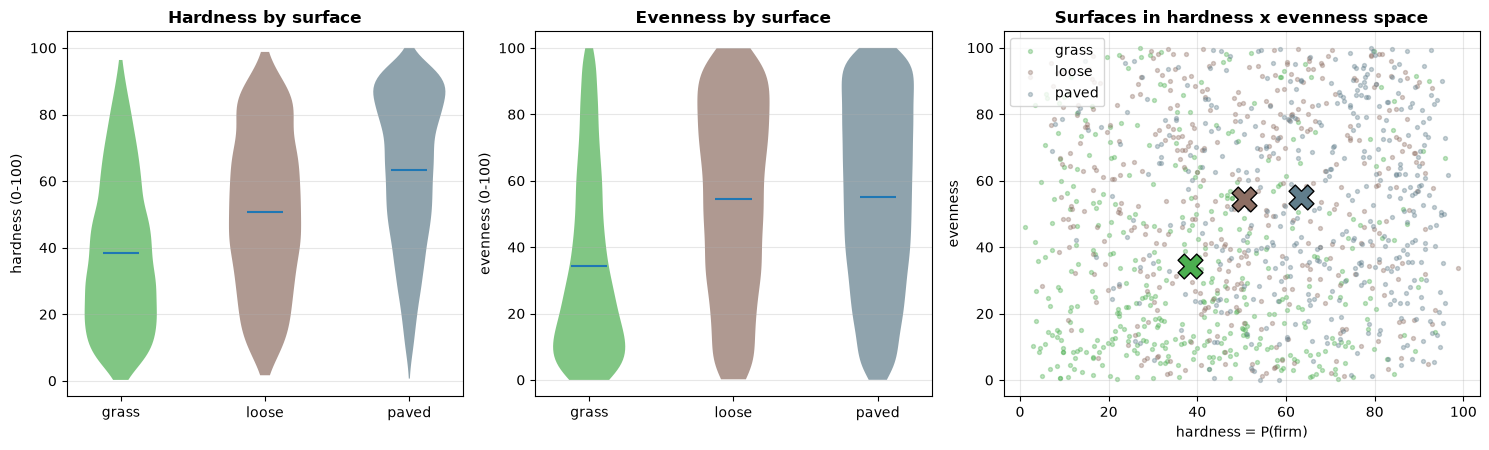

In [18]:
# ===== (D) hardness + evenness scales and surface populations =====
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.pipeline import Pipeline as _PL

SOFT = {'grass', 'soft'}
COMPL = [c for c in ['accel_jerk_ratio','accel_hf_frac','accel_spec_centroid','accel_zcr','gyro_hf_frac',
                     'gu_stance_frac','stance_duration','loading_rate_norm'] if c in full_df.columns]
hard_y = (~full_df['surface'].isin(SOFT)).astype(int).values; grp = full_df['source_recording'].values
oofh = np.zeros(len(full_df)); Xc2 = full_df[COMPL].fillna(0).values
if len(np.unique(hard_y)) == 2:
    for tr, te in _SGK(5, shuffle=True, random_state=42).split(Xc2, hard_y, grp):
        pl = _PL([('s', _SS()), ('lr', _LR(max_iter=1000, class_weight='balanced'))])
        pl.fit(Xc2[tr], hard_y[tr]); oofh[te] = pl.predict_proba(Xc2[te])[:, 1]
    full_df['hardness'] = oofh * 100
else:
    full_df['hardness'] = 50.0
EVEN_NEG = [c for c in ['orient_range_a','orient_range_b','gu_cop_wander','gu_press_jitter',
                        'orient_rest_a_roll3_std','orient_rest_b_roll3_std','gyro_x_std'] if c in full_df.columns]
ze = ((full_df[EVEN_NEG] - full_df[EVEN_NEG].mean()) / full_df[EVEN_NEG].std()).clip(-4, 4)
full_df['evenness'] = (-ze).mean(1).rank(pct=True) * 100
print('Mean scale position by surface:')
print(full_df.groupby('surface')[['hardness', 'evenness']].mean().round(1).to_string())
full_df[['surface','source_user','hardness','evenness']].to_csv(os.path.join(CHARTS_DIR, 'scales_scored.csv'), index=False)

_cl = sorted(full_df['surface'].unique())
fig = plt.figure(figsize=(15, 4.6)); gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])
for k, sca in enumerate(['hardness', 'evenness']):
    ax = fig.add_subplot(gs[0, k]); data = [full_df[full_df.surface == s][sca].values for s in _cl]
    parts = ax.violinplot(data, showmeans=True, showextrema=False)
    for pc, s in zip(parts['bodies'], _cl): pc.set_facecolor(SURFACE_COLORS.get(s, '#9E9E9E')); pc.set_alpha(.7)
    ax.set_xticks(range(1, len(_cl)+1)); ax.set_xticklabels(_cl); ax.set_ylabel(f'{sca} (0-100)')
    ax.set_title(f'{sca.capitalize()} by surface', fontweight='bold'); ax.grid(axis='y', alpha=.3)
ax = fig.add_subplot(gs[0, 2])
for s in _cl:
    d = full_df[full_df.surface == s].sample(min(400, int((full_df.surface == s).sum())), random_state=1)
    ax.scatter(d.hardness, d.evenness, s=8, alpha=.35, color=SURFACE_COLORS.get(s, '#9E9E9E'), label=s)
    ax.scatter(full_df[full_df.surface == s].hardness.mean(), full_df[full_df.surface == s].evenness.mean(),
               s=320, color=SURFACE_COLORS.get(s, '#9E9E9E'), edgecolor='k', marker='X', zorder=5)
ax.set_xlabel('hardness = P(firm)'); ax.set_ylabel('evenness'); ax.legend()
ax.set_title('Surfaces in hardness x evenness space', fontweight='bold'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'scales_populations.png'), dpi=140, bbox_inches='tight'); plt.show()

## 12. Per-surface feature summary statistics

For every feature the model uses (`FEATURE_COLS`), the count / mean / std / min / median / max **within each surface class**, plus an overall row. Also writes a tidy CSV (`feature_summary_by_surface.csv`) and a wide mean±std table you can drop into the write-up. The ANOVA F column (higher = better class separation) lets you sort features by how strongly they differ across surfaces.

In [19]:
# ===== per-surface summary statistics for every model feature =====
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler as _SS

_df = train_df.copy()
_feats = list(FEATURE_COLS)
_surfaces = list(classes)

# (1) tidy long-form: one row per (feature, surface) with the usual stats
_stat_names = ['count','mean','std','min','25%','50%','75%','max']
_rows = []
for f in _feats:
    for s in _surfaces:
        d = _df.loc[_df['surface'] == s, f].replace([np.inf,-np.inf], np.nan).dropna()
        desc = d.describe()
        row = {'feature': f, 'surface': s}
        row.update({k: (float(desc[k]) if k in desc else np.nan) for k in _stat_names})
        _rows.append(row)
    # overall (all surfaces) row
    d = _df[f].replace([np.inf,-np.inf], np.nan).dropna(); desc = d.describe()
    row = {'feature': f, 'surface': 'ALL'}
    row.update({k: (float(desc[k]) if k in desc else np.nan) for k in _stat_names})
    _rows.append(row)
summary_long = pd.DataFrame(_rows)

# (2) ANOVA F per feature (class separation), attach to the long table
_F, _p = f_classif(_SS().fit_transform(_df[_feats].fillna(0).values), _df['surface'].values)
_fser = pd.Series(_F, index=_feats)
summary_long['anova_F'] = summary_long['feature'].map(_fser).round(2)
summary_long = summary_long.sort_values(['anova_F','feature','surface'], ascending=[False,True,True])

# (3) compact wide view: mean (std) per surface, one row per feature, F-sorted
def _fmt(m, s): return f"{m:.3g} ({s:.2g})" if pd.notna(m) else ""
_wide = {}
for f in _feats:
    rec = {'anova_F': round(float(_fser[f]), 1)}
    for s in _surfaces:
        d = _df.loc[_df['surface'] == s, f].replace([np.inf,-np.inf], np.nan).dropna()
        rec[f'{s}: mean(std)'] = _fmt(d.mean(), d.std())
    _wide[f] = rec
summary_wide = pd.DataFrame(_wide).T
summary_wide = summary_wide.reindex(_fser.sort_values(ascending=False).index)   # F-sorted
summary_wide.index.name = 'feature'

# (4) save + show
_long_path = os.path.join(CHARTS_DIR, 'feature_summary_by_surface.csv')
_wide_path = os.path.join(CHARTS_DIR, 'feature_summary_mean_std_wide.csv')
summary_long.to_csv(_long_path, index=False)
summary_wide.to_csv(_wide_path)
print(f'wrote {_long_path}')
print(f'wrote {_wide_path}')
print(f'\n{len(_feats)} features x {len(_surfaces)} surfaces  (F-sorted; mean (std) per surface):')
try:
    from IPython.display import display
    display(summary_wide)
except Exception:
    print(summary_wide.to_string())

wrote ..\model_outputs\3class\Charts_Graphs\feature_summary_by_surface.csv
wrote ..\model_outputs\3class\Charts_Graphs\feature_summary_mean_std_wide.csv

36 features x 3 surfaces  (F-sorted; mean (std) per surface):


,anova_F,grass: mean(std),loose: mean(std),paved: mean(std)
feature,,,,
orient_rest_a_roll3_std,2237.9,1.85 (1.1),1.03 (0.72),0.827 (0.66)
gyro_x_std,1127.4,4.1e+06 (2.7e+05),4.19e+06 (2.4e+05),4.33e+06 (2.6e+05)
accel_jerk_ratio,1043.3,0.49 (0.041),0.461 (0.036),0.456 (0.039)
orient_rest_b_roll3_std,1006.5,1.78 (1.2),1.14 (0.93),0.959 (0.86)
accel_spec_centroid,606.4,4.14 (0.46),4.25 (0.49),4.47 (0.55)
accel_hf_frac,585.0,0.202 (0.07),0.225 (0.074),0.251 (0.08)
accel_spec_entropy,583.6,0.522 (0.049),0.529 (0.051),0.557 (0.062)
gyro_hf_frac,411.4,0.201 (0.044),0.207 (0.038),0.224 (0.048)
heel_ripple_frac,346.2,0.00192 (0.0011),0.00183 (0.00078),0.0024 (0.0013)


## 13. Box-and-whisker plots by surface

A boxplot per feature, split by surface class (box = IQR, line = median, whiskers = 1.5×IQR, points beyond = outliers). Features are ordered by ANOVA F (most class-separating first), and each value is z-scored **within the feature** so all panels share a comparable y-scale — you're reading whether the coloured boxes sit apart (separates the classes) or overlap (doesn't). Saves `feature_boxplots.png`.

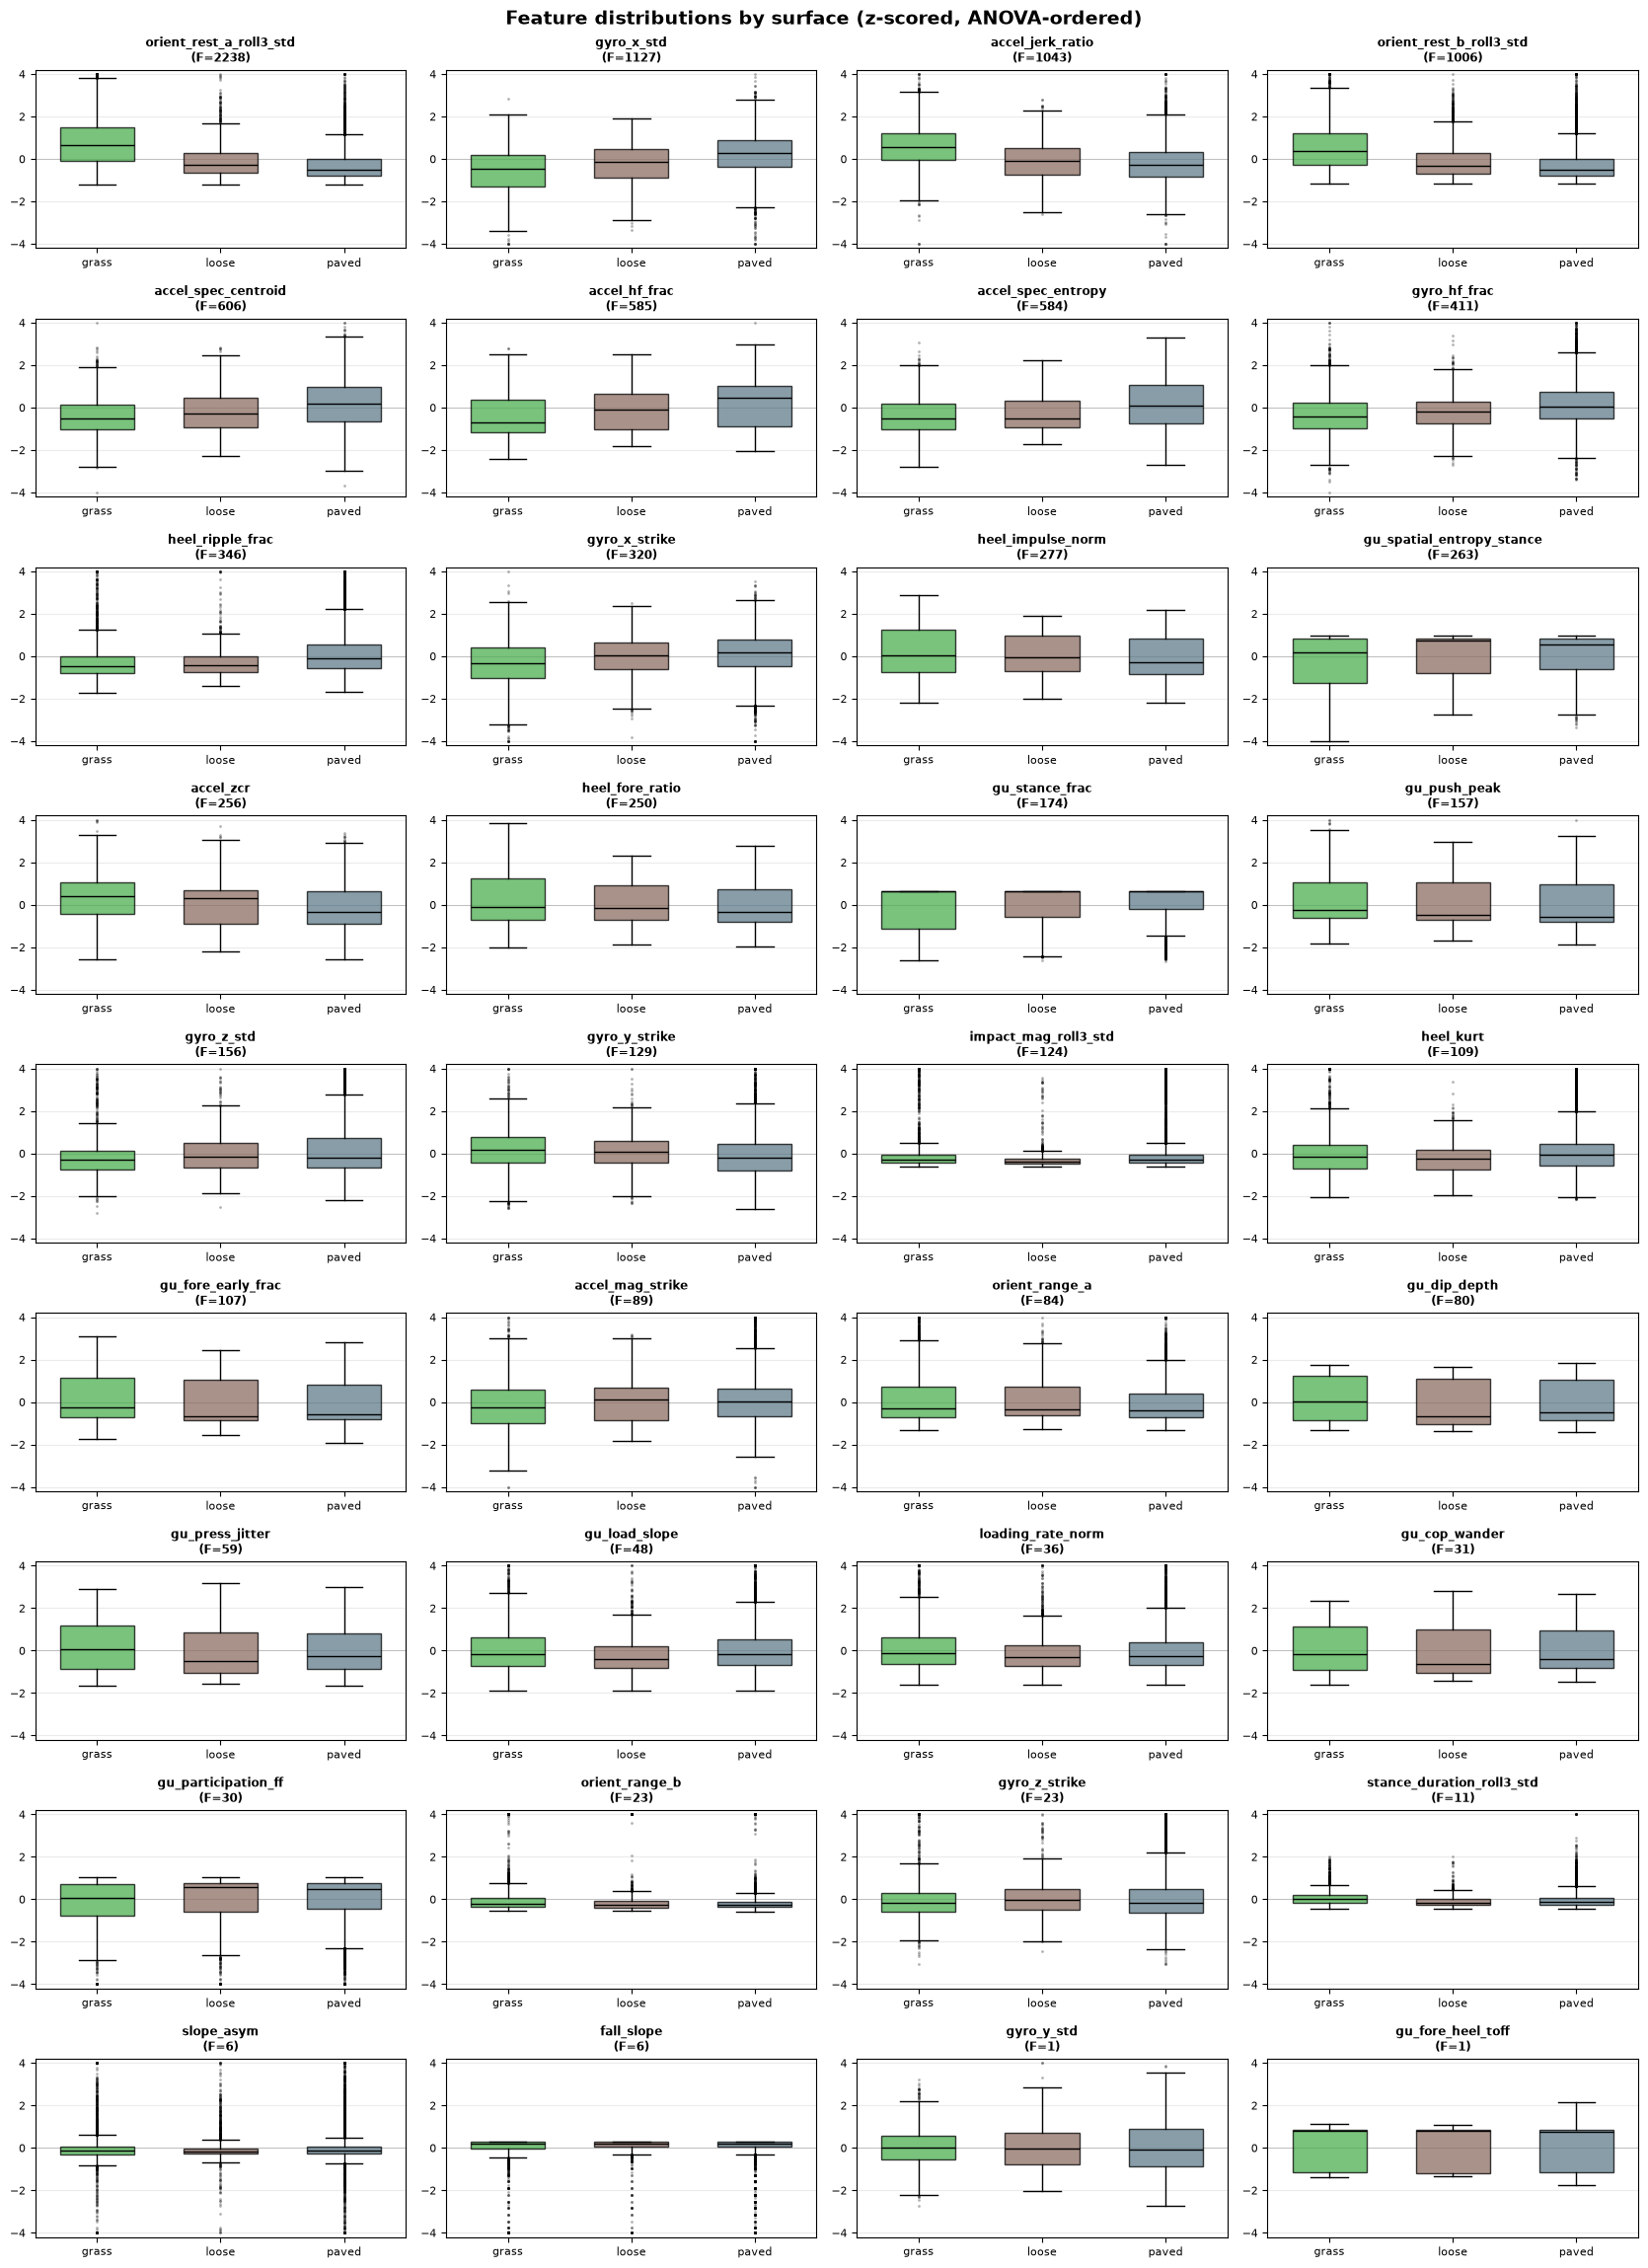

wrote ..\model_outputs\3class\Charts_Graphs\feature_boxplots.png


In [20]:
# ===== box-and-whisker plots of every model feature, by surface =====
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler as _SS

_feats = list(FEATURE_COLS); _surfaces = list(classes)
_X = _df_num = train_df[_feats].replace([np.inf,-np.inf], np.nan)

# order features by class-separation (ANOVA F)
_F, _p = f_classif(_SS().fit_transform(train_df[_feats].fillna(0).values), train_df['surface'].values)
_order = pd.Series(_F, index=_feats).sort_values(ascending=False).index.tolist()

# z-score each feature so panels are visually comparable (robust to the feature's own scale)
_z = (_X - _X.mean()) / _X.std(ddof=0)
_z['surface'] = train_df['surface'].values

_ncol = 4
_nrow = int(np.ceil(len(_order) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(_ncol*4.2, _nrow*2.6))
axes = np.atleast_1d(axes).ravel()
for ax, feat in zip(axes, _order):
    data = [ _z.loc[_z['surface']==s, feat].replace([np.inf,-np.inf], np.nan).dropna().clip(-4,4).values
             for s in _surfaces ]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_xticks(range(1, len(_surfaces)+1)); ax.set_xticklabels([str(s)[:5] for s in _surfaces])
    for patch, s in zip(bp['boxes'], _surfaces):
        patch.set_facecolor(SURFACE_COLORS.get(s, '#9E9E9E')); patch.set_alpha(0.75)
    for med in bp['medians']: med.set_color('black')
    ax.set_title(f"{feat}\n(F={pd.Series(_F, index=_feats)[feat]:.0f})", fontsize=8.5, fontweight='bold')
    ax.tick_params(labelsize=8); ax.axhline(0, color='#bbb', lw=0.6, zorder=0); ax.grid(axis='y', alpha=0.25)
    ax.set_ylim(-4.2, 4.2)
for ax in axes[len(_order):]:
    ax.set_visible(False)
fig.suptitle('Feature distributions by surface (z-scored, ANOVA-ordered)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.99])
plt.savefig(os.path.join(CHARTS_DIR, 'feature_boxplots.png'), bbox_inches='tight', dpi=140)
plt.show()
print('wrote', os.path.join(CHARTS_DIR, 'feature_boxplots.png'))